# Geometric observables for FSI topology classification

`event-analysis` showed that averaging per-PFO classifier scores across an
event carries little topology information. This notebook looks for observables
that do: geometric quantities describing the final state relative to the
incoming beam particle.

Three groups:
1. **Leading shower** — the highest-energy shower in the event, its energy and
   its orientation relative to the beam.
2. **Reconstructed π⁰** — mass, opening angle and momentum, which should
   separate charge exchange specifically.
3. **Event shape** — multiplicity, total visible energy, and the angular
   spread of the final state.

The output is a ranking of which observables separate which topology.

In [1]:
import pickle
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

from utils.general_utils import (PROJECT_ROOT, SPECIES_COLORS,
                                 species_label, target_config)
from utils.topology_utils import (Pi0Reconstructor, classify_topology,
                                  pi0_candidate, shower_dir_vec,
                                  TRUE_ORDER, TRUE_LABELS,
                                  MASS_CUT, PHI_CUT, PI0_MASS)

PION_CFG   = target_config("pion")
PHOTON_CFG = target_config("photon")

PREPARED_DIR = PROJECT_ROOT / "prepared" / "prepared-mc"
PRED_MC_DIR  = PROJECT_ROOT / "predictions" / "predictions-mc"
PLOTS_DIR    = PROJECT_ROOT / "plots" / "fsi-observables"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

with open(PREPARED_DIR / "test_tracks.pkl", "rb") as f:
    tracks = pickle.load(f)

species = np.array([species_label(t) for t in tracks])
print(f"{len(tracks):,} PFOs")

126,817 PFOs


# what fields are available

In [2]:
# Before building anything, see what the ntuple gives us. Some of the
# observables below need beam direction or momentum, which may not have been
# extracted; this cell says which are possible.
keys = sorted(tracks[0].keys())
print(f"{len(keys)} fields per PFO:\n")
for k in keys:
    v = tracks[0][k]
    kind = type(v).__name__
    if isinstance(v, dict):
        kind = f"dict{sorted(v.keys())}"
    elif isinstance(v, (list, np.ndarray)):
        kind = f"{kind}[{len(v)}]"
    print(f"  {k:<32} {kind}")

WANTED = ['beam_end_pos', 'beam_start_pos', 'beam_direction', 'beam_KE',
          'shower_start_pos', 'shower_direction', 'shower_energy', 'E_c',
          'b', 'd', 'event_number']
print("\nneeded for the observables below:")
for w in WANTED:
    print(f"  {w:<20} {'YES' if w in keys else 'MISSING'}")

27 fields per PFO:

  E_c                              float
  PFO_ID                           int
  b                                float
  beam_KE                          float
  beam_angle                       float
  beam_end_pos                     dict['x', 'y', 'z']
  beam_inst_P                      float
  beam_inst_dir                    dict['x', 'y', 'z']
  beam_start_pos                   dict['x', 'y', 'z']
  d                                float
  dEdX_median                      float
  dEdX_sequence                    ndarray[222]
  event_number                     int
  is_gamma_from_beam_pi0           bool
  n_hits                           int
  n_hits_collection                int
  particle                         str
  pi0_mother_id                    int
  residual_range_sequence          ndarray[222]
  sequence_length                  int
  shower_direction                 dict['x', 'y', 'z']
  shower_energy                    float
  shower_start_pos     

## build the event index and truth

In [3]:
rec = Pi0Reconstructor(tracks)
ev_idx, n_ev, idx_by_event = rec.ev_idx, rec.n_ev, rec.idx_by_event
print(f"{n_ev:,} events")

def per_event(mask):
    return np.bincount(ev_idx[mask], minlength=n_ev)

true_pion_mask   = np.array([PION_CFG['is_signal'](t)   for t in tracks])
true_photon_mask = np.array([PHOTON_CFG['is_signal'](t) for t in tracks])

n_true_pi    = per_event(true_pion_mask)
n_true_gamma = per_event(true_photon_mask)
true_pi0     = rec.true_pi0.astype(int)

true_topo = np.array([classify_topology(n_true_pi[e], n_true_gamma[e], true_pi0[e])
                      for e in range(n_ev)])

for t in TRUE_ORDER:
    print(f"  {t:<24} {int((true_topo == t).sum()):>7,} events")


# --- beam axis ---------------------------------------------------------------
# beam_direction is not in the extraction. beam_end_pos is, and it varies event
# to event because the beam particle interacts at different depths. The
# principal axis of that point cloud therefore approximates the beam direction.
def xyz(rec_):
    return np.array([float(rec_['x']), float(rec_['y']), float(rec_['z'])])

first_pfo = [idx_by_event[e][0] for e in range(n_ev)]
ends = np.array([xyz(tracks[i]['beam_end_pos']) for i in first_pfo])

centre = ends.mean(axis=0)
_, sv, vt = np.linalg.svd(ends - centre, full_matrices=False)
BEAM_AXIS = vt[0] / np.linalg.norm(vt[0])
if BEAM_AXIS[2] < 0:
    BEAM_AXIS = -BEAM_AXIS                      # point downstream

ratio = sv[0] / sv[1]
print(f"\nbeam end centroid : {centre.round(1)}")
print(f"singular values   : {sv.round(1)}   ratio 1st/2nd = {ratio:.2f}")
print(f"derived beam axis : {BEAM_AXIS.round(4)}")
print(f"angle to +z       : {np.degrees(np.arccos(abs(BEAM_AXIS[2]))):.2f} deg")

if ratio < 3:
    BEAM_AXIS = np.array([0.0, 0.0, 1.0])
    print("\nWARNING: vertex cloud is not elongated enough to fix a direction.")
    print("Falling back to +z. State this if the angle observables are shown.")
else:
    print("\nVertex cloud is elongated; the derived axis is usable.")

38,082 events
  pion_production            7,864 events
  single_pion_production     8,920 events
  charge_exchange            5,127 events
  absorption                14,491 events

beam end centroid : [-49.6 398.7 118.4]
singular values   : [17309.8  2369.4  1561.2]   ratio 1st/2nd = 7.31
derived beam axis : [-0.2026 -0.2203  0.9542]
angle to +z       : 17.42 deg

Vertex cloud is elongated; the derived axis is usable.


## geometric observables

In [4]:
def angle_between(u, v):
    nu, nv = np.linalg.norm(u), np.linalg.norm(v)
    if nu == 0 or nv == 0:
        return np.nan
    return float(np.degrees(np.arccos(np.clip(np.dot(u, v) / (nu * nv), -1, 1))))

E_shower = np.array([float(t['shower_energy']) for t in tracks])
E_c      = np.array([float(t.get('E_c', np.nan)) for t in tracks])
b_arr    = np.array([float(t['b']) for t in tracks])
d_arr    = np.array([float(t['d']) for t in tracks])
ts_arr   = np.array([float(t['track_score']) for t in tracks])
tl_arr   = np.array([float(t['track_length']) for t in tracks])

OBS_NAMES = [
    'leading shower energy [MeV]',
    'leading shower angle to beam [deg]',
    'leading shower angle to vertex [deg]',
    'leading shower b [cm]',
    'leading shower d [cm]',
    'n showers (track score < 0.45)',
    'total visible energy [MeV]',
    'max opening angle between showers [deg]',
    'pi0 mass [MeV]',
    'pi0 opening angle [deg]',
    'pi0 momentum [MeV]',
    'pi0 angle to beam [deg]',
    'longest track length [cm]',
    'event multiplicity',
]
obs = {k: np.full(n_ev, np.nan) for k in OBS_NAMES}

# pi0 built from TRUE photons: this is the ceiling, not what is reachable.
chosen, _ = rec.select(true_photon_mask, pairing="best")

for e in range(n_ev):
    members = idx_by_event[e]
    obs['event multiplicity'][e] = len(members)

    showers = [i for i in members if ts_arr[i] < 0.45 and np.isfinite(E_shower[i])]
    obs['n showers (track score < 0.45)'][e] = len(showers)

    if showers:
        lead = max(showers, key=lambda i: E_shower[i])
        sd = shower_dir_vec(tracks[lead])
        obs['leading shower energy [MeV]'][e] = E_shower[lead]
        obs['leading shower b [cm]'][e] = b_arr[lead]
        obs['leading shower d [cm]'][e] = d_arr[lead]
        obs['leading shower angle to beam [deg]'][e] = angle_between(sd, BEAM_AXIS)
        # independent of the beam-axis approximation:
        v_vertex = xyz(tracks[lead]['shower_start_pos']) - xyz(tracks[lead]['beam_end_pos'])
        obs['leading shower angle to vertex [deg]'][e] = angle_between(sd, v_vertex)

        if len(showers) > 1:
            angs = [angle_between(shower_dir_vec(tracks[i]), shower_dir_vec(tracks[j]))
                    for k, i in enumerate(showers) for j in showers[k+1:]]
            angs = [a for a in angs if np.isfinite(a)]
            if angs:
                obs['max opening angle between showers [deg]'][e] = max(angs)

    tot = np.nansum([E_shower[i] for i in members])
    obs['total visible energy [MeV]'][e] = tot if tot > 0 else np.nan

    tls = [tl_arr[i] for i in members if np.isfinite(tl_arr[i])]
    if tls:
        obs['longest track length [cm]'][e] = max(tls)

    if e in chosen:
        i, j = chosen[e]
        mass, phi = pi0_candidate(tracks[i], tracks[j])
        if mass is not None:
            di = shower_dir_vec(tracks[i]); dj = shower_dir_vec(tracks[j])
            p = (E_c[i] * di / np.linalg.norm(di)) + (E_c[j] * dj / np.linalg.norm(dj))
            obs['pi0 mass [MeV]'][e]          = mass
            obs['pi0 opening angle [deg]'][e] = phi
            obs['pi0 momentum [MeV]'][e]      = float(np.linalg.norm(p))
            obs['pi0 angle to beam [deg]'][e] = angle_between(p, BEAM_AXIS)

for k in OBS_NAMES:
    v = obs[k]
    print(f"  {k:<42} finite: {np.isfinite(v).sum():>7,} / {n_ev:,}")

  leading shower energy [MeV]                finite:  23,262 / 38,082
  leading shower angle to beam [deg]         finite:  23,262 / 38,082
  leading shower angle to vertex [deg]       finite:  23,262 / 38,082
  leading shower b [cm]                      finite:  23,262 / 38,082
  leading shower d [cm]                      finite:  23,262 / 38,082
  n showers (track score < 0.45)             finite:  38,082 / 38,082
  total visible energy [MeV]                 finite:  38,082 / 38,082
  max opening angle between showers [deg]    finite:  11,519 / 38,082
  pi0 mass [MeV]                             finite:   2,297 / 38,082
  pi0 opening angle [deg]                    finite:   2,297 / 38,082
  pi0 momentum [MeV]                         finite:   2,297 / 38,082
  pi0 angle to beam [deg]                    finite:   2,297 / 38,082
  longest track length [cm]                  finite:  38,082 / 38,082
  event multiplicity                         finite:  38,082 / 38,082


## Decompose the pi0 reconstruction loss

In [5]:
# Decompose the pi0 reconstruction loss. Uses TRUE photons throughout, so
# every loss below is reconstruction or kinematics, not tagging.
from collections import defaultdict

true_gamma_per_ev = per_event(true_photon_mask)
has_true_pi0 = rec.true_pi0

stage = defaultdict(int)
for e in np.where(has_true_pi0)[0]:
    members = idx_by_event[e]
    gams = [i for i in members if true_photon_mask[i]]

    if len(gams) < 2:
        stage['only 1 photon reconstructed'] += 1
        continue

    # same-mother pairs only: two photons from different pi0 are not a signal pair
    pairs = [(i, j) for k, i in enumerate(gams) for j in gams[k+1:]
             if tracks[i]['pi0_mother_id'] == tracks[j]['pi0_mother_id']]
    if not pairs:
        stage['2+ photons, none share a mother'] += 1
        continue

    finite = [(i, j) for i, j in pairs
              if np.isfinite(E_c[i]) and np.isfinite(E_c[j])]
    if not finite:
        stage['pair exists, E_c missing'] += 1
        continue

    passed = False
    for i, j in finite:
        mass, phi = pi0_candidate(tracks[i], tracks[j])
        if mass is not None and mass < MASS_CUT and phi < PHI_CUT:
            passed = True
            break
    stage['RECONSTRUCTED' if passed else 'pair exists, fails mass/angle cut'] += 1

tot = int(has_true_pi0.sum())
print(f"{tot:,} events with a true pi0\n")
for k in ['only 1 photon reconstructed', '2+ photons, none share a mother',
          'pair exists, E_c missing', 'pair exists, fails mass/angle cut',
          'RECONSTRUCTED']:
    v = stage.get(k, 0)
    print(f"  {k:<38}{v:>7,}  ({100*v/tot:5.1f}%)")

# How much of the E_c loss is the low-energy cutoff?
gam_idx = np.where(true_photon_mask)[0]
n_nan = int(np.isnan(E_c[gam_idx]).sum())
print(f"\ntrue photons with E_c undefined: {n_nan:,} / {len(gam_idx):,} "
      f"({100*n_nan/len(gam_idx):.1f}%)")
if n_nan:
    print(f"  their shower_energy: median {np.nanmedian(E_c[gam_idx][np.isnan(E_c[gam_idx])] if False else E_shower[gam_idx][np.isnan(E_c[gam_idx])]):.1f} MeV")
print(f"finite E_c range: {np.nanmin(E_c[gam_idx]):.1f} - {np.nanpercentile(E_c[gam_idx], 99):.1f} MeV")

10,703 events with a true pi0

  only 1 photon reconstructed             5,056  ( 47.2%)
  2+ photons, none share a mother           467  (  4.4%)
  pair exists, E_c missing                2,050  ( 19.2%)
  pair exists, fails mass/angle cut       1,018  (  9.5%)
  RECONSTRUCTED                           2,112  ( 19.7%)

true photons with E_c undefined: 5,160 / 19,753 (26.1%)
  their shower_energy: median 29.5 MeV
finite E_c range: 117.7 - 1208.4 MeV


## Check how many E_c are negative

In [6]:
gam = np.where(true_photon_mask)[0]
finite = E_c[gam][np.isfinite(E_c[gam])]
print(f"negative E_c: {(finite < 0).sum():,} / {len(finite):,}")
print(f"below 0 percentiles: {np.percentile(finite, [0.1, 1, 5]).round(1)}")

negative E_c: 0 / 14,593
below 0 percentiles: [117.8 118.5 122.4]


## separation power, one topology against the rest

In [7]:
# For each observable and each topology, AUC of "is this topology" vs the rest.
# This is the ranking that answers which observables are worth feeding a model.
print(f"{'observable':<42}" + "".join(f"{t.split('_')[0][:9]:>11}" for t in TRUE_ORDER))
print("-" * (42 + 11 * len(TRUE_ORDER)))

rows = []
for name, v in obs.items():
    ok = np.isfinite(v)
    if ok.sum() < 200:
        continue
    aucs = []
    for t in TRUE_ORDER:
        y = (true_topo[ok] == t).astype(int)
        aucs.append(roc_auc_score(y, v[ok]) if 0 < y.sum() < len(y) else np.nan)
    rows.append((name, aucs, max(abs(a - 0.5) for a in aucs if np.isfinite(a))))

for name, aucs, best in sorted(rows, key=lambda r: -r[2]):
    print(f"{name:<42}" + "".join(f"{a:>11.3f}" for a in aucs))

print("\n0.5 = no separation. Sorted by the strongest single-topology separation.")

observable                                       pion     single     charge  absorptio
--------------------------------------------------------------------------------------
event multiplicity                              0.753      0.463      0.465      0.359
leading shower energy [MeV]                     0.556      0.347      0.734      0.324
n showers (track score < 0.45)                  0.662      0.348      0.707      0.378
pi0 momentum [MeV]                              0.394        nan      0.606        nan
total visible energy [MeV]                      0.601      0.440      0.566      0.426
leading shower angle to vertex [deg]            0.408      0.573      0.464      0.590
leading shower angle to beam [deg]              0.456      0.580      0.422      0.555
max opening angle between showers [deg]         0.525      0.519      0.428      0.519
pi0 opening angle [deg]                         0.568        nan      0.432        nan
leading shower b [cm]                      

## distributions by topology

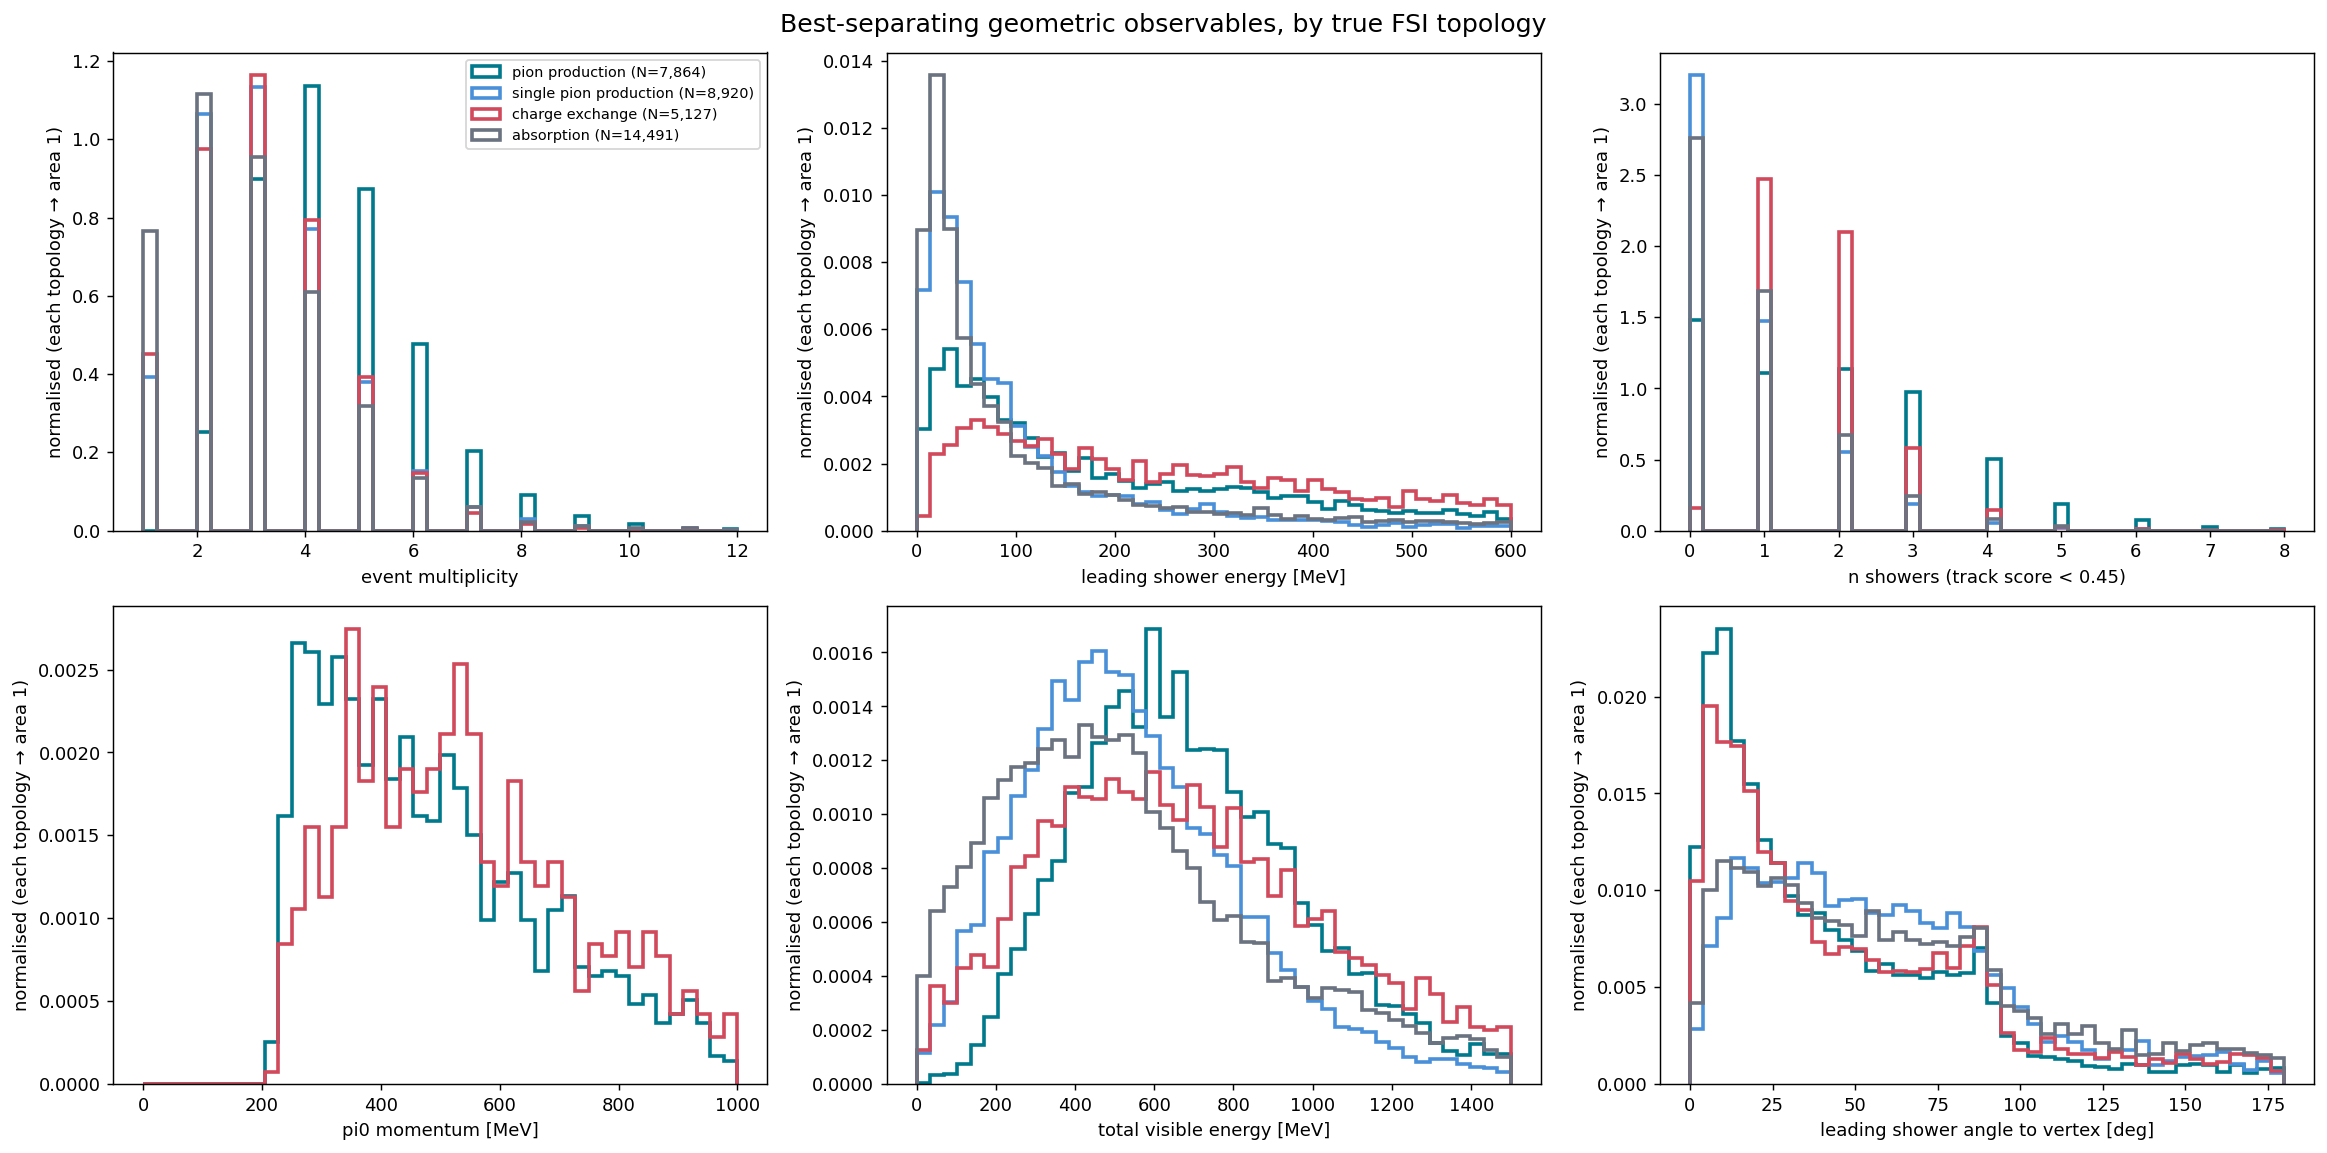

In [8]:
TOPO_COLORS = {'absorption': '#6b7280', 'charge_exchange': '#d1495b',
               'single_pion_production': '#4a90d9', 'pion_production': '#00798c'}

SHOW = [name for name, _, _ in sorted(rows, key=lambda r: -r[2])][:6]
RANGES = {
    'leading shower energy [MeV]':             (0, 600),
    'leading shower angle to beam [deg]':      (0, 180),
    'leading shower b [cm]':                   (0, 25),
    'leading shower d [cm]':                   (0, 60),
    'pi0 mass [MeV]':                          (0, 250),
    'pi0 opening angle [deg]':                 (0, 60),
    'pi0 momentum [MeV]':                      (0, 1000),
    'pi0 angle to beam [deg]':                 (0, 180),
    'total visible energy [MeV]':              (0, 1500),
    'max opening angle between showers [deg]': (0, 180),
    'longest track length [cm]':               (0, 150),
    'event multiplicity':                      (1, 12),
    'n showers (track score < 0.45)':          (0, 8),
    'leading shower angle to vertex [deg]': (0, 180),
}

fig, ax = plt.subplots(2, 3, figsize=(18, 9), dpi=130); ax = ax.ravel()
for j, name in enumerate(SHOW):
    v = obs[name]
    lo, hi = RANGES.get(name, (np.nanpercentile(v, 1), np.nanpercentile(v, 99)))
    bins = np.linspace(lo, hi, 45)
    for t, lab in zip(TRUE_ORDER, TRUE_LABELS):
        m = (true_topo == t) & np.isfinite(v)
        if m.sum() < 20:
            continue
        ax[j].hist(v[m], bins=bins, histtype='step', density=True, lw=2,
                   color=TOPO_COLORS[t], label=f"{lab.replace(chr(10), ' ')} (N={m.sum():,})")
    ax[j].set_xlabel(name)
    ax[j].set_ylabel('normalised (each topology → area 1)')
ax[0].legend(fontsize=8)
fig.suptitle('Best-separating geometric observables, by true FSI topology', fontsize=14)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "fsi_observables_by_topology.pdf", bbox_inches='tight')
plt.show()

## charge exchange specifically

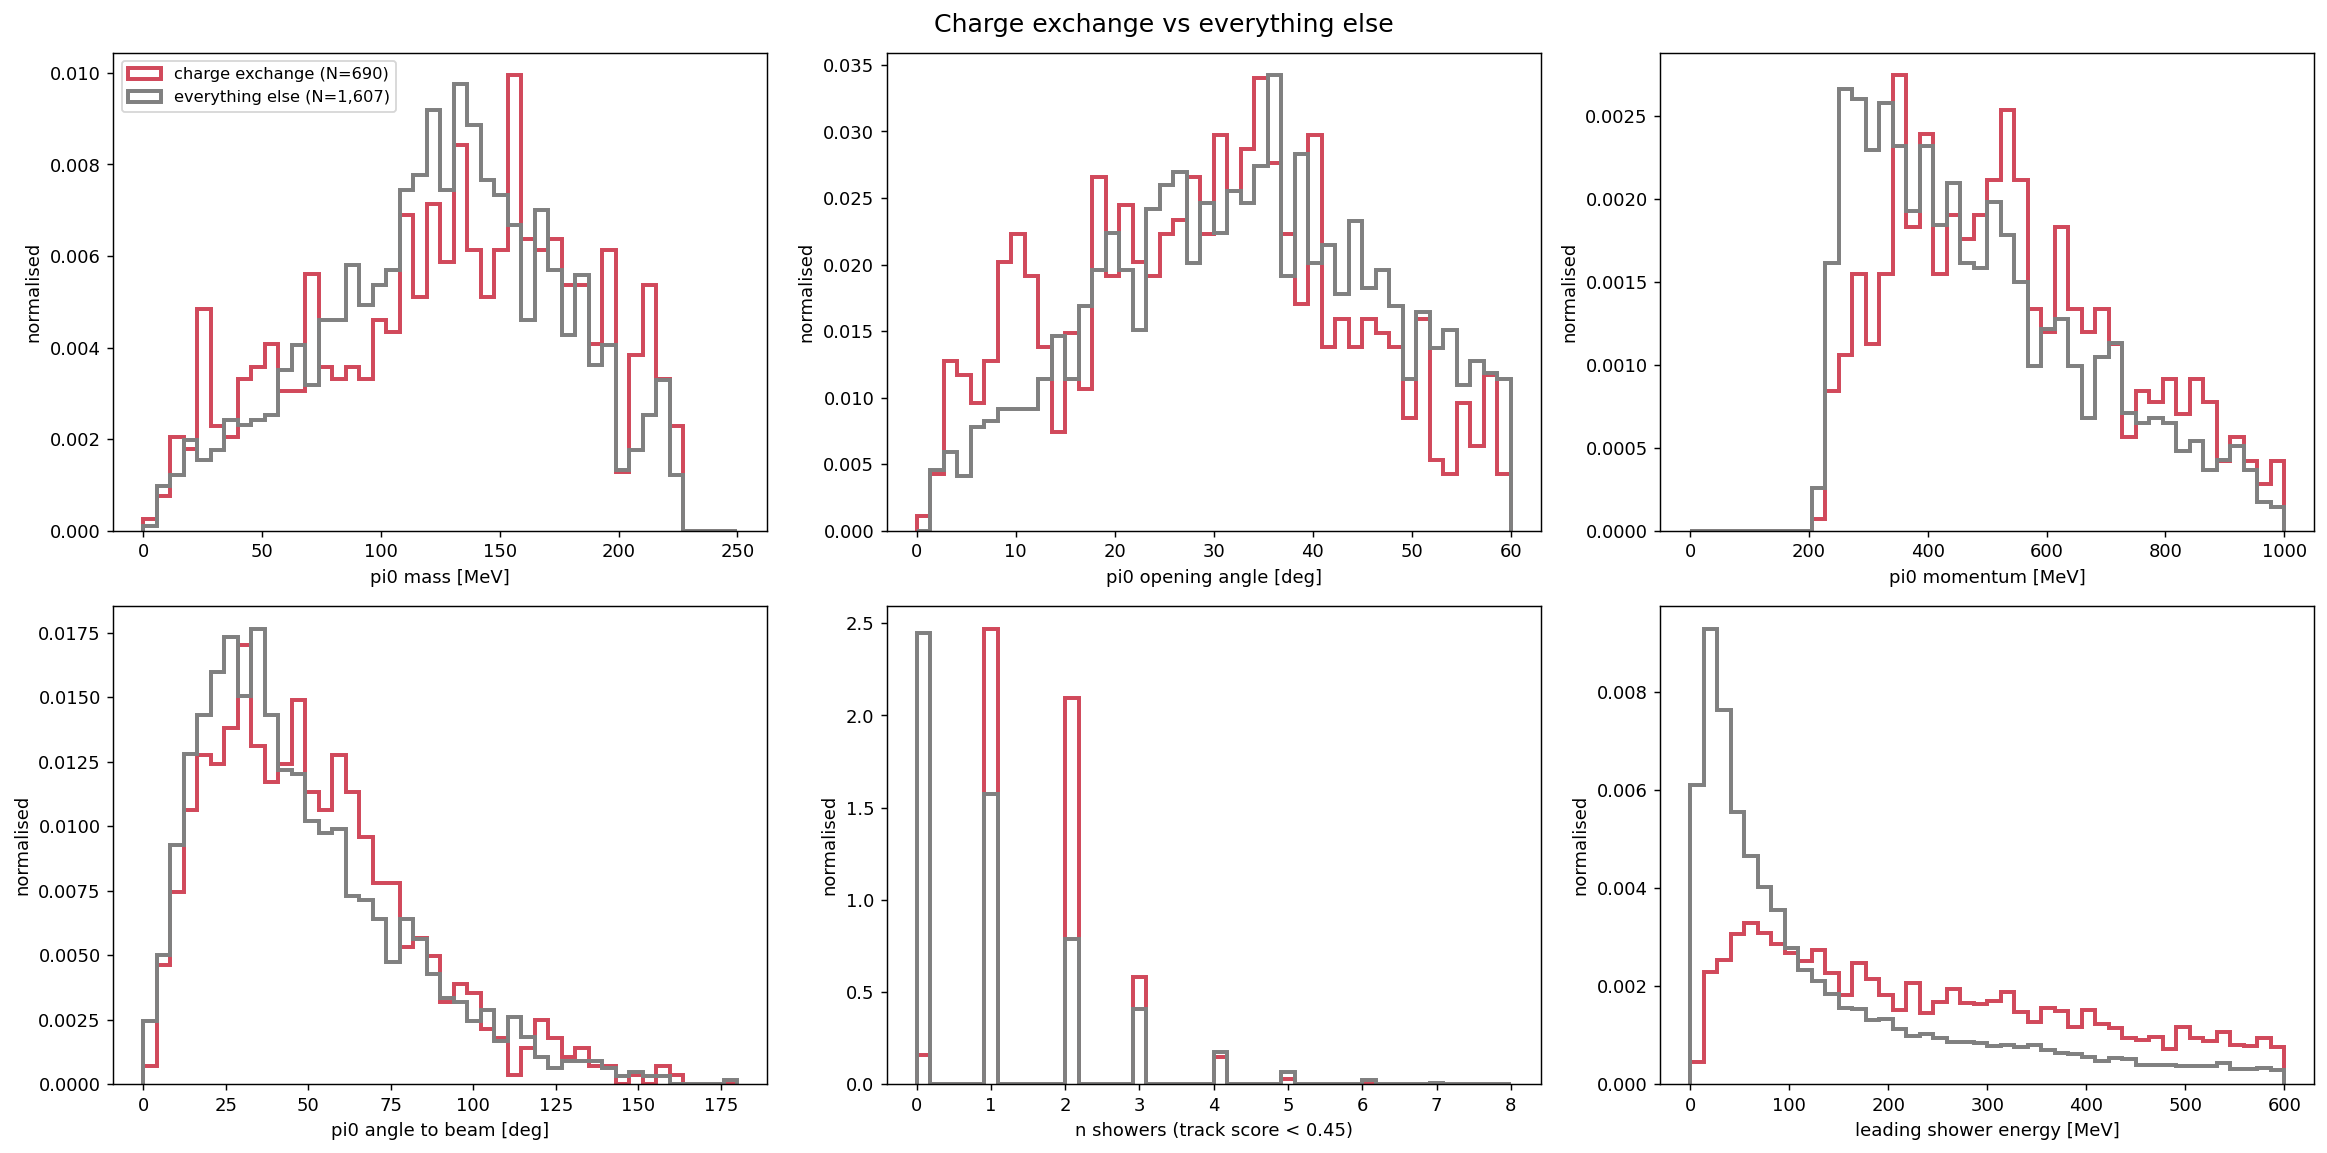

observable                                   AUC (CEX vs rest)
--------------------------------------------------------------
pi0 mass [MeV]                                           0.518
pi0 opening angle [deg]                                  0.432
pi0 momentum [MeV]                                       0.606
pi0 angle to beam [deg]                                  0.542
n showers (track score < 0.45)                           0.707
leading shower energy [MeV]                              0.734


In [9]:
# CEX is the topology that has not improved. These are the observables that
# should distinguish it: it is the one with a real pi0.
CEX_VARS = ['pi0 mass [MeV]', 'pi0 opening angle [deg]', 'pi0 momentum [MeV]',
            'pi0 angle to beam [deg]', 'n showers (track score < 0.45)',
            'leading shower energy [MeV]']

is_cex = (true_topo == 'charge_exchange')

fig, ax = plt.subplots(2, 3, figsize=(18, 9), dpi=130); ax = ax.ravel()
for j, name in enumerate(CEX_VARS):
    v = obs[name]
    lo, hi = RANGES[name]
    bins = np.linspace(lo, hi, 45)
    ok = np.isfinite(v)
    ax[j].hist(v[ok & is_cex],  bins=bins, histtype='step', density=True, lw=2.2,
               color='#d1495b', label=f'charge exchange (N={(ok & is_cex).sum():,})')
    ax[j].hist(v[ok & ~is_cex], bins=bins, histtype='step', density=True, lw=2.2,
               color='grey', label=f'everything else (N={(ok & ~is_cex).sum():,})')
    ax[j].set_xlabel(name); ax[j].set_ylabel('normalised')
ax[0].legend(fontsize=9)
fig.suptitle('Charge exchange vs everything else', fontsize=14)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "fsi_observables_cex.pdf", bbox_inches='tight')
plt.show()

print(f"{'observable':<42}{'AUC (CEX vs rest)':>20}")
print("-" * 62)
for name in CEX_VARS:
    v = obs[name]; ok = np.isfinite(v)
    if ok.sum() > 200:
        print(f"{name:<42}{roc_auc_score(is_cex[ok], v[ok]):>20.3f}")

In [10]:
neg = finite[finite < 0]
print(f"{len(neg)} negative, {len(np.unique(neg))} distinct values")
print(np.unique(neg)[:10])

0 negative, 0 distinct values
[]
